<a href="https://colab.research.google.com/github/Denis2054/AI_Educational/blob/master/03_Toolkit_token_path.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reverse Engineering the Transformer's Path of Least Resistance

The Directed Graph of the Path of Least Resistance

# Table of Contents

In [ ]:
import json, re
from IPython.display import HTML, display

path = "Toolkit_token_path.ipynb"  # change to your file
with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

def parse_headings(cells, max_level=4):
    items = []
    for cell in nb["cells"]:
        if cell.get("cell_type") == "markdown":
            src = "".join(cell.get("source", []))
            for line in src.splitlines():
                m = re.match(r'^(#{1,%d})\s+(.*)$' % max_level, line)
                if m:
                    level = len(m.group(1))
                    text = m.group(2).strip()
                    items.append((level, text))
    return items

def slug(s):
    s = s.lower()
    s = re.sub(r"\s+", "-", s)
    s = re.sub(r"[^\w\-]", "", s)
    return s

items = parse_headings(nb["cells"], max_level=4)
html = ['<div class="copilot-toc"><div class="copilot-toc-title">Table of contents</div><ol>']
stack = [1]  # current level
for level, text in items:
    while stack[-1] > level:
        html.append("</ol></li>")
        stack.pop()
    while stack[-1] < level:
        html.append("<li><ol>")
        stack.append(stack[-1]+1)
    html.append(f'<li class="lvl-{level}"><a href="#{slug(text)}">{text}</a></li>')
# close tags
while len(stack) > 1:
    html.append("</ol></li>")
    stack.pop()
html.append("</ol></div>")


css = """
<style>
.copilot-toc { border: 1px solid #e0e0e0; border-radius: 8px; padding: 12px 14px; margin: 12px 0 18px; background: #fafafa; }
.copilot-toc-title { font-weight: 600; font-size: 16px; margin: 0 0 8px; }
.copilot-toc ol { list-style: none; padding-left: 0; margin: 0; }
.copilot-toc li { margin: 4px 0; }
.copilot-toc a { text-decoration: none; color: #1a73e8; }
.copilot-toc a:hover { text-decoration: underline; }
.lvl-1 { font-weight: 600; }
.lvl-2 { padding-left: 12px; }
.lvl-3 { padding-left: 24px; }
.lvl-4 { padding-left: 36px; }
</style>
"""
display(HTML(css + "".join(html)))

Sequence of operations:

1.  **Raw Logits:** The model's final layer outputs a raw, unnormalized score for every token in its vocabulary. These scores are called **logits**.

2.  **Temperature Scaling:** Before the softmax, these logits are divided by the **temperature** value.
    * Your notebook doesn't specify one, so it defaults to `1.0` (no change).
    * A temperature `< 1.0` would make the distribution sharper (more confident).
    * A temperature `> 1.0` would make it flatter (more random).

3.  **Softmax Function:** The (scaled) logits are fed into the **softmax function**. This is the step that converts the scores into a true probability distribution, where all the token probabilities are positive and add up to 1.

4.  **Log Probs:** The API then takes the **natural logarithm ($\ln$)** of each of those probabilities from the softmax output. These are the `logprobs` values you receive.

They are converted back to probalities for top k, top p and multinomial selections.

**Top-P** (with Normalization)
Top-p sampling, or nucleus sampling, is a dynamic filtering method applied before the final random selection to create a smaller, more relevant pool of candidate tokens. Let's apply it to your notebook's example with a hypothetical p value of 0.5. First, the model sorts the tokens by their probability and cumulatively sums them until the total reaches the p threshold, creating an exclusive candidate pool of just [' year', ' beginning', ' start'] with original probabilities of ~29.1%, ~16.4%, and ~11.2% respectively. Next, and crucially, it performs a normalization step: these probabilities are recalculated so they sum to 100% within their new, smaller group. For example, the ~29.1% chance for ' year' becomes a much larger ~51% chance within this specific pool. The final step is to perform the multinomial selection (the weighted random draw) on this newly created, normalized probability distribution, ensuring the choice is made from a set of plausible options.

**Top-K**(with Normalization)
Top-k sampling is a straightforward filtering method that restricts the model's choices to a fixed number of the most likely options before the final selection. Using your notebook's example with a hypothetical k value of 3, the process begins by creating a candidate pool of only the top three tokens: [' year', ' beginning', ' start'], with their original probabilities of ~29.1%, ~16.4%, and ~11.2%. Before the final selection, the model performs a critical normalization step: it adjusts these three probabilities proportionally so that their new values sum to 100%. In this renormalized distribution, the ~29.1% probability for ' year' would be scaled up to become a ~51% chance relative to the other two candidates. The final step is to perform the multinomial selection (the weighted random draw) on this new, normalized distribution of just three options, guaranteeing the choice is always made from a predictable number of the most sensible tokens.

**Multinomial** sampling is applied and is the weighted random selection process that explains why the model chose 'best' over the more probable 'year'. The process unfolds in three steps using the probabilities derived from the output. First, the model converts the log probabilities into actual probabilities, giving 'year' a ~29.1% chance and 'best' a much smaller ~6.8% chance. Next, it conceptually lays out these probabilities on a number line from 0 to 1, where 'year' occupies the first large segment (0 to 0.291) and 'best' occupies a smaller segment further down (e.g., from 0.567 to 0.635). The final step is to generate a single random number between 0 and 1; for your specific output to occur, this random number must have landed within the small segment corresponding to 'best', causing its selection despite the lower odds. This method is fundamental to an LLM's creativity, as it allows the model to make less obvious but still plausible choices instead of always picking the most predictable token.

## Installation

## Token-level logprobs

In [ ]:
# Imports and API Key Setup
# We will use the OpenAI library to interact with the LLM and Google Colab's
# secret manager to securely access your API key.

import os
from openai import OpenAI
from google.colab import userdata

# Load the API key from Colab secrets, set the env var, then init the client
try:
    api_key = userdata.get("API_KEY")
    if not api_key:
        raise userdata.SecretNotFoundError("API_KEY not found.")

    # Set environment variable for downstream tools/libraries
    os.environ["OPENAI_API_KEY"] = api_key

    # Create client (will read from OPENAI_API_KEY)
    client = OpenAI()
    print("OpenAI API key loaded and environment variable set successfully.")

except userdata.SecretNotFoundError:
    print('Secret "API_KEY" not found.')
    print('Please add your OpenAI API key to the Colab Secrets Manager.')
except Exception as e:
    print(f"An error occurred while loading the API key: {e}")


OpenAI API key loaded and environment variable set successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openai

In [ ]:
import openai
openai.api_key = api_key

# Stream of Consciousness

When deterministic prompts collide with probablistic systems.

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
#prompt="Complete the following sentence: This could be"
#filename="completion_3.txt"

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
#prompt="Complete the following sentence: Hello"
#filename="hello_superposition.txt"

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
#prompt="Complete the following sentence: A woman walked"
#filename="A_woman_walked03.txt"

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
#prompt="Complete the following sentence: The best dish is"
#filename="The_best_dish.txt"

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
#prompt="Complete the following sentence: Semantic drifting is"
#filename="Semantic_drifting.txt"

In [ ]:
#High degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
prompt="Complète la phrase suivante avec la citation exacte de Marcel Proust dans la Recherche du Temps Perdu: ...le propre du romancier est"
filename="Proust_01.txt"

'''
Mais il me semble que notre temps fait une confusion de genres et
que le propre du romancier est plutôt de nouer une intrigue
et d’élever les coeurs que de fignoler à la pointe sèche un frontispice
ou un cul-de-lampe. Je verrai votre père dimanche chez ce brave A.J., ajouta-t-il en se tournant vers moi.

Le Côté Guermantes,1921,Partie 2
Proust, Marcel. A la recherche du temps perdu (l'intégrale) . e-artnow. Édition du Kindle.
'''

In [ ]:
# Medium degrees of freedom. Undirected prompt for a directed probablistic graph
# A case of superposed semiotics: prody, context, body language
#prompt="Complete the following sentence: She walked out"
#filename="She_walked_out04.txt"

In [ ]:
#Low degree of freedom.
#prompt="What is the capital of France:"
#filename="Hard_fact_general_01.txt"

In [ ]:
#Low degree of freedom with a semantic gap because of the specilized semantic gap category 2 but with a strong hint
#prompt="Que fait Mademoiselle de Vinteuil sur le canapé dans la Recherche du Temps Perdu de Marcel Proust:"
#filename="Hard_fact_general_01.txt"

In [ ]:
#Low degree of freedom with a semantic gap because of the specilized semantic gap category 2 but with a no hint
#prompt="Que fait le romancier à la réalité la Recherche du Temps Perdu de Marcel Proust:"
#filename="Hard_fact_general_01.txt"

## Logprobs

The code uses **log base $e$ (natural logarithm, $\ln$)** for the log probabilities.

This is standard practice for language models like the one accessed via the OpenAI API.



1.  **Log Probability Parameter:** The line `logprobs=10` in the API call requests the model to return the log probability for the selected token and the log probabilities for the top 10 most likely alternative tokens for each position.
2.  **Standard LLM Output:** When a Large Language Model (LLM) like GPT-3.5-turbo-instruct returns log probabilities (often denoted as $\log P$ or $\log p$), these values are typically the **natural logarithm ($\ln$)** of the actual probability ($P$) of the token given the preceding text.
    * **Formula:** $\log P = \ln(P)$
    * **Why $\ln$?:** The natural logarithm is used because the underlying mathematical framework (based on information theory and continuous probability distributions) often relies on the base $e$.
3.  **Interpretation:**
    * Since probability $P$ is between $0$ and $1$, the log probability $\ln(P)$ will be a **non-positive number** (less than or equal to 0).
    * The closer the log probability is to **$0$**, the higher the probability $P$ is (e.g., $\ln(1) = 0$).
    * A highly negative number indicates a very low probability (e.g., $\ln(0.01) \approx -4.605$).



In [ ]:
import openai
import os
def gentoken(filename, prompt: str):
    """
    Generates text using the OpenAI API based on a given prompt and displays
    a detailed breakdown of the generation process, including log probabilities
    for each token and its alternatives.

    Args:
        filename (str): The name of the .txt file to save the output to.
        prompt (str): The input text to prompt the model with.
    """

    # --- Start Change 1: Open file and create logger function ---
    # Open the file in write mode. The 'with' block handles closing it.
    with open(filename, 'w', encoding='utf-8') as f:

        def log(message):
            """A simple helper to print to console AND write to file."""
            print(message)      # Prints to the console
            f.write(message + '\n') # Writes the same message to the file

        # --- End Change 1 ---

        # --- Start Change 2: All 'print' calls are now 'log' ---
        log(f"🚀 Sending prompt: '{prompt}'")
        try:
            # Make the API call to OpenAI
            response = openai.completions.create(
                model="gpt-3.5-turbo-instruct",
                prompt=prompt,
                max_tokens=500,
                logprobs=10,  # Request the top 10 alternative tokens
                temperature=0.7
            )

            choice = response.choices[0]

            # --- Display Generated Text ---
            log("\n" + "="*50)
            log("✅ COMPLETED GENERATION")
            log("="*50)
            log(f"'{prompt}{choice.text}'")


            # --- Display Detailed Token Information ---
            if hasattr(choice, "logprobs") and choice.logprobs:
                logprobs_obj = choice.logprobs
                tokens = logprobs_obj.tokens
                token_logprobs = logprobs_obj.token_logprobs
                top_logprobs = logprobs_obj.top_logprobs

                # Common End-Of-Sequence (EOS) tokens, which can vary by model
                eos_keyword_list = ["<|endoftext|>", "", "<eos>"]

                log("\n" + "="*50)
                log("🔎 TOKEN-BY-TOKEN BREAKDOWN")
                log("="*50)

                for i, tok in enumerate(tokens):
                    log(f"\n--- Token {i}: {repr(tok)} ---")
                    log(f"Logprob: {token_logprobs[i]:.4f}")

                    if top_logprobs and i < len(top_logprobs):
                        log("Top Candidates:")
                        candidates = top_logprobs[i]
                        for cand, lp in candidates.items():
                            log(f"  - {repr(cand)}: {lp:.4f}")

                        # Check if an EOS token was a candidate
                        for eos in eos_keyword_list:
                            if eos in candidates:
                                log(f"  ⭐ EOS detected as a candidate with logprob {candidates[eos]:.4f}")
                    else:
                        log("  No top candidates available for this token.")

            else:
                log("\nLogprobs data was not returned in the API response.")

        except openai.AuthenticationError:
            log("\n🚨 Error: Authentication failed. Please check your OpenAI API key.")
            log("Ensure it's set correctly as an environment variable or in your script.")
        except Exception as e:
            log(f"\n🚨 An unexpected error occurred: {e}")
        # --- End Change 2 ---

In [ ]:
# Run 1: Completing a sentence
gentoken(filename,prompt)
!cp {filename} "/content/drive/MyDrive/XArchema/Knowledge /00-Token_analysis/"

🚀 Sending prompt: 'Complète la phrase suivante avec la citation exacte de Marcel Proust dans la Recherche du Temps Perdu: ...le propre du romancier est'

✅ COMPLETED GENERATION
'Complète la phrase suivante avec la citation exacte de Marcel Proust dans la Recherche du Temps Perdu: ...le propre du romancier est de "rendre la vie plus vaste".

"Le propre du romancier est de ne pas donner une image exacte de la vie, mais de la rendre plus vaste." '

🔎 TOKEN-BY-TOKEN BREAKDOWN

--- Token 0: ' de' ---
Logprob: -0.2270
Top Candidates:
  - ' de': -0.2270
  - ' d': -2.0488
  - '...': -4.1148
  - '...\n\n': -4.1366
  - '\n\n': -5.1393
  - ' "': -5.4283
  - ' non': -6.0027
  - ' ...': -6.0884
  - ',': -6.1856
  - '..."': -6.3071

--- Token 1: ' "' ---
Logprob: -4.3807
Top Candidates:
  - ' faire': -1.8773
  - ' nous': -2.0632
  - ' pr': -2.6078
  - ' ...': -2.7074
  - '\n\n': -2.8283
  - '...': -2.9920
  - '...\n\n': -3.1632
  - ' ne': -3.7408
  - ' ...\n\n': -3.7813
  - ' découvrir': -3.9081

--

## Graph

Reading and parsing log file: Proust_01.txt
Building graph...
Drawing graph with matplotlib...
Graph saved to Proust_01.png


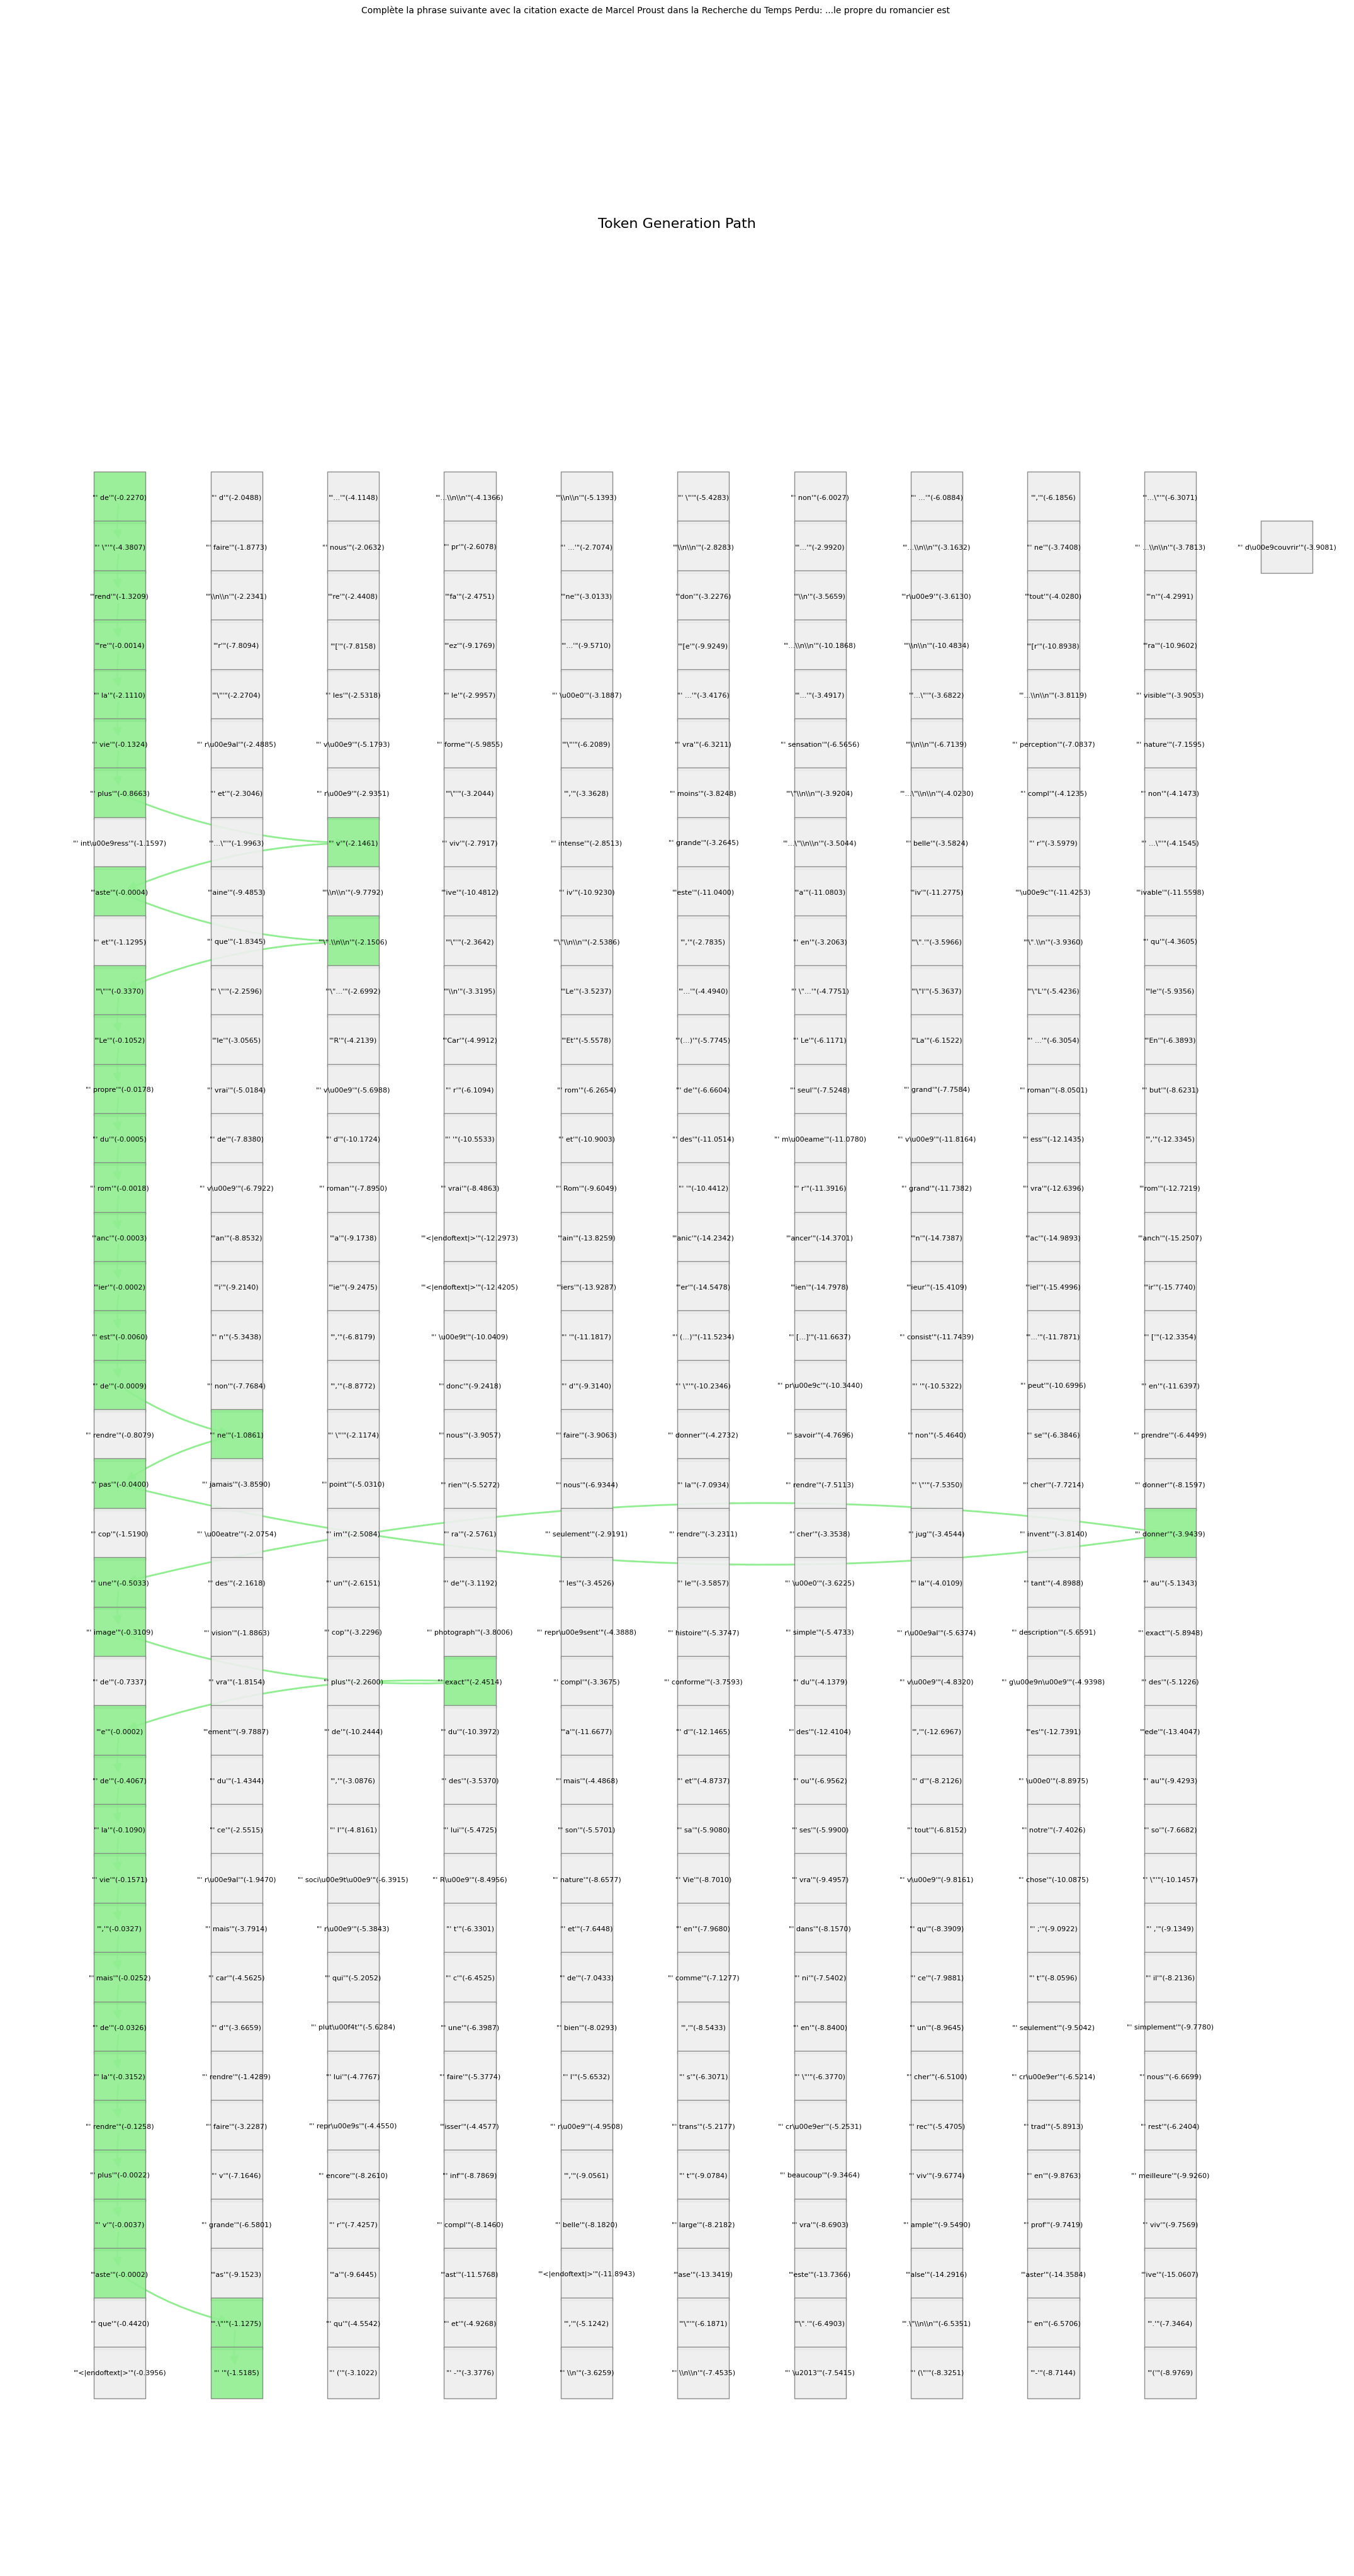

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import re
import json

# --- 1. Data Parsing Function ---
def parse_token_data(file_content):
    """Parses the raw log text into a structured list of token steps."""
    steps = []
    # Regex to find each token block
    token_sections = re.split(r'--- Token \d+: ', file_content)[1:]

    for i, section in enumerate(token_sections):
        step_data = {}
        # Regex to find the chosen token and its logprob
        chosen_match = re.search(r"(.+?) ---\nLogprob: ([\-\.\de]+)", section, re.DOTALL)
        if not chosen_match:
            continue

        chosen_token = chosen_match.group(1).strip()
        chosen_logprob = float(chosen_match.group(2))
        step_data['chosen'] = (chosen_token, chosen_logprob)

        candidates = []
        # Regex to find the 'Top Candidates' block
        candidates_match = re.search(r'Top Candidates:\n(.*?)(?=\n\n|\n---|\Z)', section, re.DOTALL)
        if candidates_match:
            candidates_text = candidates_match.group(1)
            # Regex to find each candidate line, ignoring junk prefixes
            candidate_lines = re.findall(r'[ \w]?- \s*(.+?):\s*([\-\.\de]+)', candidates_text)
            for tok, lp in candidate_lines:
                candidates.append((tok.strip(), float(lp)))

        step_data['candidates'] = candidates
        steps.append(step_data)
    return steps

# --- 2. Main Graphing Logic ---

# Set the filename that was declared in the notebook
log_filename = filename

print(f"Reading and parsing log file: {log_filename}")
try:
    with open(log_filename, "r", encoding="utf-8") as f:
        content = f.read()

    # --- NEW: Extract the prompt from the file content ---
    prompt_match = re.search(r"🚀 Sending prompt: '(.+?)'", content)
    prompt_text = prompt_match.group(1) if prompt_match else "Prompt not found in file"
    # ---

    steps = parse_token_data(content)

except FileNotFoundError:
    print(f"Error: File not found '{log_filename}'.")
    print("Please ensure the cell that creates or saves this file was run first.")
    steps = []
    prompt_text = ""
except Exception as e:
    print(f"Error reading file: {e}")
    steps = []
    prompt_text = ""

if steps:
    print("Building graph...")
    graph = nx.DiGraph()

    labels = {}
    pos = {}
    node_colors = []
    node_list = []

    last_chosen_node_id = None
    max_candidates_per_step = 0

    # Process each step to create nodes, edges, and positions
    for i, step in enumerate(steps):
        y_pos = -i * 2
        (chosen_token, chosen_lp) = step['chosen']
        all_candidates = step['candidates']

        if not any(t == chosen_token for t, lp in all_candidates):
            all_candidates.insert(0, (chosen_token, chosen_lp))

        if len(all_candidates) > max_candidates_per_step:
            max_candidates_per_step = len(all_candidates)

        current_chosen_node_id = None

        for j, (cand_token, cand_lp) in enumerate(all_candidates):
            x_pos = j
            node_id = f"step{i}_cand{j}"
            label = f"{json.dumps(cand_token)}({cand_lp:.4f})"

            graph.add_node(node_id)
            labels[node_id] = label
            pos[node_id] = (x_pos, y_pos)
            node_list.append(node_id)

            if cand_token == chosen_token:
                node_colors.append('lightgreen')
                current_chosen_node_id = node_id
            else:
                node_colors.append('#EEEEEE')

        if last_chosen_node_id and current_chosen_node_id:
            graph.add_edge(last_chosen_node_id, current_chosen_node_id, color='lightgreen', weight=2)

        last_chosen_node_id = current_chosen_node_id

    # --- 3. Draw the Graph ---
    print("Drawing graph with matplotlib...")

    edge_colors = [graph[u][v].get('color', 'gray') for u, v in graph.edges()]
    edge_widths = [graph[u][v].get('weight', 1) for u, v in graph.edges()]

    fig_width = max(max_candidates_per_step * 2.5, 15)
    fig_height = max(len(steps) * 1.2, 8)

    plt.figure(figsize=(fig_width, fig_height))

    nx.draw_networkx_nodes(graph, pos, nodelist=node_list,
                           node_color=node_colors, node_shape='s',
                           node_size=3500, alpha=0.9,
                           edgecolors='gray')

    nx.draw_networkx_edges(graph, pos, edge_color=edge_colors,
                           width=edge_widths, arrows=True, arrowsize=20,
                           connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(graph, pos, labels=labels, font_color='black', font_size=8)

    # --- MODIFIED: Add both title and subtitle (prompt) ---
    plt.title('Token Generation Path', size=16, y=1.03) # Adjust title position
    plt.suptitle(prompt_text, size=10, y=0.98) # Use the extracted prompt
    # ---

    plt.axis('off')

    # Save the figure *before* showing it
    png_filename = log_filename.replace('.txt', '.png')
    plt.savefig(png_filename, bbox_inches='tight')
    print(f"Graph saved to {png_filename}")

    plt.show()

else:
    print("No token steps were parsed. Cannot draw graph.")

In [ ]:
!cp {png_filename} "/content/drive/MyDrive/XArchema/Knowledge /00-Token_analysis/"

## Token ids

In [ ]:
# First, ensure tiktoken is installed
#!pip install tiktoken -q

import tiktoken
import re
import json
import os # For handling filenames

# --- 1. Function to read the log file and extract the chosen tokens ---
def extract_chosen_tokens_from_file(filename_to_read):
    """Reads a log file and extracts the list of chosen token strings."""
    try:
        with open(filename_to_read, "r", encoding="utf-8") as f:
            content = f.read()
    except FileNotFoundError:
        print(f"Error: File '{filename_to_read}' not found.")
        print("Please ensure the cell that saves the file has been run.")
        return []

    chosen_tokens = []
    # Split the content by the "--- Token" separator
    token_sections = re.split(r'--- Token \d+: ', content)[1:]

    for section in token_sections:
        # Find the chosen token, which is on the first line of the section
        chosen_match = re.search(r"(.+?) ---\nLogprob:", section, re.DOTALL)
        if chosen_match:
            token_with_quotes = chosen_match.group(1).strip()
            # Extract the raw string from inside the quotes
            if len(token_with_quotes) > 1 and token_with_quotes.startswith("'") and token_with_quotes.endswith("'"):
                raw_token = token_with_quotes[1:-1]
                chosen_tokens.append(raw_token)

    return chosen_tokens

# --- 2. Function to determine token completeness ---
def get_completeness_label(token_str):
    """
    Determines if a token string is 'Complete' (starts a new word)
    or 'Incomplete' (is a sub-word).

    Heuristic: 'Complete' tokens typically start with a space or
    are non-alphanumeric (like newlines or punctuation).
    """
    if not token_str:
        return "Unknown"

    # Check the first character.
    first_char = token_str[0]

    # If it's not an alphanumeric character (e.g., ' ', '\n', ':', '"')
    # it's considered a "Complete" token.
    if not first_char.isalnum():
        return "Complete"
    else:
        # (e.g., 'import', 'ance', 'Daily')
        return "Incomplete"

# --- 3. Function to analyze, PRINT, and SAVE the tokens ---
def analyze_and_print_and_save(token_list, output_filename):
    """
    Encodes tokens, gets their completeness, and both prints
    and saves the analysis to a file.
    """
    if not token_list:
        print("No tokens were extracted to analyze.")
        return

    try:
        # Get the tokenizer for the "cl100k_base" encoding
        tokenizer = tiktoken.get_encoding("cl100k_base")
    except Exception as e:
        print(f"Error initializing tokenizer: {e}")
        return

    print(f"--- Analyzing tokens and saving to {output_filename} ---")

    output_lines = []
    output_lines.append("--- Analysis of Selected Tokens ---")
    output_lines.append("-" * 60)

    for token_str in token_list:
        # Get the token ID
        token_id_list = tokenizer.encode(token_str)
        token_id = token_id_list[0] if token_id_list else "N/A"

        # Get the completeness label
        label = get_completeness_label(token_str)

        # Format the line
        line = f"Token: {repr(token_str):<25} | ID: {str(token_id):<8} | Label: {label}"
        output_lines.append(line)

    # Now, print and save the results
    try:
        with open(output_filename, 'w', encoding='utf-8') as f:
            for line in output_lines:
                print(line)      # 1. Display the output
                f.write(line + '\n') # 2. Save the output

        print("-" * 60)
        print(f"Token analysis saved successfully to '{output_filename}'")

    except Exception as e:
        print(f"An error occurred while writing to file: {e}")


# --- 4. Execution ---

# 1. Use the 'filename' variable from the global scope
try:
    # Check if 'filename' exists
    if 'filename' not in locals() and 'filename' not in globals():
        print("Error: 'filename' variable not found.")
        print("Please run the cell that defines 'filename' (e.g., filename = 'completion_1.txt') first.")
    else:
        input_log_filename = filename  # Use the global variable

        # 2. Create the new output filename
        base_name = os.path.splitext(input_log_filename)[0]
        output_token_filename = f"{base_name}_tokens.txt"

        # 3. Run the functions
        selected_tokens = extract_chosen_tokens_from_file(input_log_filename)
        analyze_and_print_and_save(selected_tokens, output_token_filename)

except NameError:
    print("Error: The variable 'filename' is not defined.")
    print("Please run the cell that defines 'filename' first.")

--- Analyzing tokens and saving to Proust_01_tokens.txt ---
--- Analysis of Selected Tokens ---
------------------------------------------------------------
Token: ' de'                     | ID: 409      | Label: Complete
Token: ' "'                      | ID: 330      | Label: Complete
Token: 'rend'                    | ID: 9484     | Label: Incomplete
Token: 're'                      | ID: 265      | Label: Incomplete
Token: ' la'                     | ID: 1208     | Label: Complete
Token: ' vie'                    | ID: 17536    | Label: Complete
Token: ' plus'                   | ID: 5636     | Label: Complete
Token: ' v'                      | ID: 348      | Label: Complete
Token: 'aste'                    | ID: 5642     | Label: Incomplete
Token: '".\\n\\n'                | ID: 3343     | Label: Complete
Token: '"'                       | ID: 1        | Label: Complete
Token: 'Le'                      | ID: 2356     | Label: Incomplete
Token: ' propre'                 | ID: 8318

In [ ]:
!cp {output_token_filename} "/content/drive/MyDrive/XArchema/Knowledge /00-Token_analysis/"

# GPT-5.1

In [ ]:
from openai import OpenAI
client = OpenAI()

def genoutput(prompt: str):
    response = client.chat.completions.create(
        model="gpt-5.1",
        messages=[
            {
                "role": "user",
                "content": prompt,
            },
        ],
    )
    output=response.choices[0].message.content
    return output

In [ ]:
# List to store all generated sequences
all_sequences = []

print("--- Generating 50 Sequences ---")
# We'll try to print the prompt, but wrap it in case it's not defined yet
try:
    print(f"Prompt: \"{prompt}\"")
except NameError:
    print("Warning: 'prompt' variable not yet defined.")

# Loop 50 times, as requested
for i in range(50):
    # 1. Call your generation function
    #    (This will fail if 'genoutput' or 'prompt' are not defined)
    try:
        sequence = genoutput(prompt)

        # 2. Store the sentence in the list
        all_sequences.append(sequence)

        # 3. Print the output in real-time with a 1-based index
        print(f"{i + 1}. {sequence}")

    except NameError as e:
        print(f"\nError on iteration {i+1}: {e}")
        print("Please make sure 'genoutput' and 'prompt' are defined in a previous cell.")
        break # Stop the loop if there's a problem
    except Exception as e:
        print(f"\nAn error occurred during generation {i+1}: {e}")
        break

print("--- Generation Complete ---")
print(f"Total sequences stored: {len(all_sequences)}")

# --- File Writing Logic ---

# 1. Parse the filename to remove the extension (.txt)
# rsplit('.', 1) splits the string once from the right at the period.
# [0] takes the part before the period (the base name).
base_name = filename.rsplit('.', 1)[0] if '.' in filename else filename

# 2. Construct the new output filename
output_filename = f"{base_name}_sequences.txt"

print(f"Writing sequences to file: {output_filename}")

# 3. Write all sequences to the file
try:
    with open(output_filename, 'w', encoding='utf-8') as f:
        for index, sequence in enumerate(all_sequences):
            # Write the sequence with a 1-based index and a newline
            f.write(f"{index + 1}. {sequence}\n")

    print(f"Successfully wrote {len(all_sequences)} sequences to {output_filename}")

except IOError as e:
    print(f"Error writing to file {output_filename}: {e}")

# --------------------------

--- Generating 50 Sequences ---
Prompt: "Complète la phrase suivante avec la citation exacte de Marcel Proust dans la Recherche du Temps Perdu: ...le propre du romancier est"
1. La phrase complète est :

> « …le propre du romancier n’est pas d’exprimer sa pensée personnelle, mais la pensée de personnages imaginaires. »
2. La phrase complète est :

> « …le propre du romancier est d’avoir de l’esprit **comme les femmes**. »  

Elle se trouve dans *À l’ombre des jeunes filles en fleurs* (deuxième tome de *À la recherche du temps perdu*).
3. La phrase complète est :

> « ...le propre du romancier est d’avoir, dans la vie, comme des dames employées à la haute couture ont, dans la rue, l’air toujours un peu mal “ficelé” parce qu’elles reportent tout le soin de leur toilette aux toilettes qu’elles font pour des clientes... »  

Elle se trouve dans *Le Temps retrouvé*, vers le début de la grande réflexion sur l’art du roman.
4. La phrase complète est :

> « …le propre du romancier est d’avoir 

In [ ]:
!cp {output_filename} "/content/drive/MyDrive/XArchema/Knowledge /00-Token_analysis/"

In [ ]:
import re
from collections import defaultdict

# This cell assumes 'all_sequences' exists in memory from running Cell 1.

print("--- Starting Word Frequency Analysis ---")

if 'all_sequences' in locals() and all_sequences:

    # 1. Create a dictionary to hold word frequencies
    #    defaultdict(int) automatically initializes new keys with a value of 0
    word_counts = defaultdict(int)

    print(f"Processing {len(all_sequences)} sequences...")

    # 2. Process each sentence in the list
    for sentence in all_sequences:
        # Use regex to find all words (sequences of word characters)
        # \b ensures we match whole words
        # .lower() makes the count case-insensitive
        words = re.findall(r'\b\w+\b', sentence.lower())

        # 3. Tally the frequency of each word
        for word in words:
            word_counts[word] += 1

    # 4. Sort the dictionary by frequency (value)
    #    .items() converts the dict to a list of (key, value) tuples
    #    key=lambda item: item[1] tells sorted() to use the *second* item
    #    in each tuple (the count) for sorting.
    #    reverse=True sorts from highest to lowest frequency.
    sorted_word_counts = sorted(
        word_counts.items(),
        key=lambda item: item[1],
        reverse=True
    )

    print("\n--- Word Frequency Report (Sorted) ---")

    # 5. Print the sorted list
    for word, count in sorted_word_counts:
        print(f"'{word}': {count}")

    print("\nAnalysis complete.")

else:
    print("Error: 'all_sequences' list not found or is empty.")
    print("Please run Cell 1 first to generate the sequences.")


--- Starting Word Frequency Analysis ---
Processing 50 sequences...

--- Word Frequency Report (Sorted) ---
'est': 113
'la': 101
'du': 78
'le': 74
'de': 67
'complète': 52
'romancier': 52
'phrase': 51
'propre': 51
'd': 40
'dans': 37
'à': 36
'temps': 36
'l': 25
'avoir': 24
'n': 23
'pas': 23
'recherche': 23
'mais': 22
'les': 22
'perdu': 21
'se': 20
'nous': 19
'qu': 18
'des': 17
'un': 15
'retrouvé': 15
'faire': 15
'elle': 14
'trouve': 14
'comme': 12
'voir': 12
'choses': 11
'dire': 11
'il': 11
'elles': 10
'plus': 10
'et': 10
'vie': 9
'proust': 9
'esprit': 8
'en': 8
'une': 8
'que': 8
'sa': 7
'ce': 7
'qui': 7
'être': 7
'pensée': 6
'toujours': 6
'sur': 6
'dernier': 6
'volume': 6
'exprimer': 5
'cette': 5
'sont': 5
'marcel': 5
'c': 4
'même': 4
'forme': 4
'telle': 4
'personnelle': 3
'ombre': 3
'jeunes': 3
'filles': 3
'fleurs': 3
'leur': 3
'aux': 3
'grande': 3
'précisément': 3
'formule': 3
'apparaît': 3
'formulation': 3
'autres': 3
'ne': 3
'peut': 3
'donner': 3
'sens': 3
'personnages': 2
'deuxième